# 02 — Feature Engineering para Market Risk

**Objetivo:** Construir y validar las features que alimentan el TFT y LSTM.
Entender cada feature es parte del *conceptual soundness* de SR 11-7.

**Prerrequisito:** `python run_all.py` (Stage 2 ejecutado)

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8fafc','axes.grid':True,'grid.alpha':0.4})

features = pd.read_csv(Path('../../data/raw/features.csv'), index_col=0, parse_dates=True)
print(f"Features shape: {features.shape}")
print(f"Columnas ({features.shape[1]}):")
for col in features.columns: print(f"  {col}")

Features shape: (3845, 40)
Columnas (40):
  log_return_EEM
  log_return_HYG
  log_return_LQD
  log_return_SPX
  log_return_MERVAL
  log_return_VIX
  log_return_EURUSD
  log_return_GBPUSD
  log_return_USDJPY
  yield_change_UST_2Y
  yield_change_UST_10Y
  realized_vol_EEM_21d
  realized_vol_EEM_63d
  realized_vol_EEM_250d
  realized_vol_HYG_21d
  realized_vol_HYG_63d
  realized_vol_HYG_250d
  realized_vol_SPX_21d
  realized_vol_SPX_63d
  realized_vol_SPX_250d
  vix_level
  vix_change
  vol_risk_premium
  corr_spx_hyg_63d
  corr_spx_eurusd_63d
  spx_drawdown
  spx_momentum_63d
  spx_momentum_21d
  crisis_flag
  macro_FED_FUNDS
  macro_FED_FUNDS_change
  macro_HY_SPREAD
  macro_HY_SPREAD_change
  macro_IG_SPREAD
  macro_IG_SPREAD_change
  day_of_week
  month
  quarter
  is_month_end
  is_quarter_end


## 1. Inventario de features por categoría

In [4]:
cats = {
    'Log-returns':      [c for c in features.columns if c.startswith('log_return_')],
    'Yield changes':    [c for c in features.columns if c.startswith('yield_change_')],
    'Vol realizada':    [c for c in features.columns if c.startswith('realized_vol_')],
    'Correlaciones':    [c for c in features.columns if c.startswith('corr_')],
    'Régimen':          [c for c in features.columns if c.startswith('spx_') or c=='crisis_flag' or c=='vix_level'],
    'Macro':            [c for c in features.columns if c.startswith('macro_')],
    'Temporales':       [c for c in features.columns if c in ['day_of_week','month','quarter','is_month_end','is_quarter_end']],
}
print("=== Inventario de features por categoría ===")
total = 0
for cat, cols in cats.items():
    print(f"\n  {cat} ({len(cols)}):")
    for c in cols: print(f"    - {c}")
    total += len(cols)
print(f"\n  TOTAL: {total} features")

=== Inventario de features por categoría ===

  Log-returns (9):
    - log_return_EEM
    - log_return_HYG
    - log_return_LQD
    - log_return_SPX
    - log_return_MERVAL
    - log_return_VIX
    - log_return_EURUSD
    - log_return_GBPUSD
    - log_return_USDJPY

  Yield changes (2):
    - yield_change_UST_2Y
    - yield_change_UST_10Y

  Vol realizada (9):
    - realized_vol_EEM_21d
    - realized_vol_EEM_63d
    - realized_vol_EEM_250d
    - realized_vol_HYG_21d
    - realized_vol_HYG_63d
    - realized_vol_HYG_250d
    - realized_vol_SPX_21d
    - realized_vol_SPX_63d
    - realized_vol_SPX_250d

  Correlaciones (2):
    - corr_spx_hyg_63d
    - corr_spx_eurusd_63d

  Régimen (5):
    - vix_level
    - spx_drawdown
    - spx_momentum_63d
    - spx_momentum_21d
    - crisis_flag

  Macro (6):
    - macro_FED_FUNDS
    - macro_FED_FUNDS_change
    - macro_HY_SPREAD
    - macro_HY_SPREAD_change
    - macro_IG_SPREAD
    - macro_IG_SPREAD_change

  Temporales (5):
    - day_of_week
 

## 2. Estadísticas descriptivas de features

In [5]:
desc = features.describe().T
desc['missing_pct'] = features.isnull().mean() * 100
desc['skew']        = features.skew()
desc['kurt']        = features.kurtosis()

print("Top 10 features por volatilidad (std):")
print(desc.sort_values('std', ascending=False)[['mean','std','min','max','missing_pct']].head(10).round(4))
print()
print(f"Features con >5% missing: {list(desc[desc['missing_pct']>5].index)}")

Top 10 features por volatilidad (std):
                     mean     std      min      max  missing_pct
vix_level         20.2422  9.3350   9.1400  82.6900          0.0
vol_risk_premium   3.6921  5.7821 -52.3152  24.8757          0.0
month              6.5267  3.4322   1.0000  12.0000          0.0
vix_change        -0.0039  2.0199 -17.6400  24.8600          0.0
macro_FED_FUNDS    4.8966  1.9802   0.8066   8.0780          0.0
day_of_week        2.0205  1.3994   0.0000   4.0000          0.0
quarter            2.5074  1.1204   1.0000   4.0000          0.0
macro_HY_SPREAD    3.6317  0.4341   2.8721   4.5445          0.0
crisis_flag        0.1311  0.3375   0.0000   1.0000          0.0
macro_IG_SPREAD    2.3531  0.3271   1.7445   2.8519          0.0

Features con >5% missing: []


## 3. Distribución de volatilidades realizadas (multi-ventana)

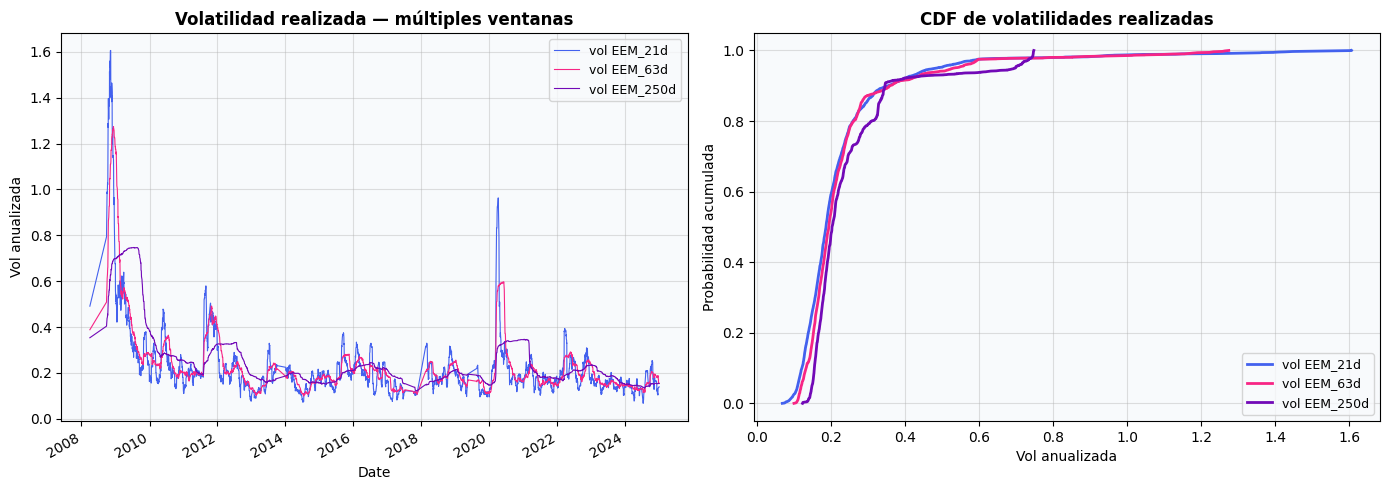

realized_vol_EEM_21d                    : mean=22.73% | max=160.59% | p99=113.79%
realized_vol_EEM_63d                    : mean=23.47% | max=127.41% | p99=114.00%
realized_vol_EEM_250d                   : mean=25.07% | max=74.73% | p99=74.56%


In [6]:
vol_cols = [c for c in features.columns if c.startswith('realized_vol_')]
if vol_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Series temporales
    ax = axes[0]
    colors = ['#4361ee','#f72585','#7209b7']
    for col, color in zip(vol_cols[:3], colors):
        features[col].plot(ax=ax, lw=0.8, color=color,
                           label=col.replace('realized_vol_','vol '))
    ax.set_title('Volatilidad realizada — múltiples ventanas', fontweight='bold')
    ax.legend(fontsize=9); ax.set_ylabel('Vol anualizada')

    # Distribución acumulada
    ax = axes[1]
    for col, color in zip(vol_cols[:3], colors):
        s = features[col].dropna()
        ax.plot(sorted(s), np.linspace(0,1,len(s)), lw=2, color=color,
                label=col.replace('realized_vol_','vol '))
    ax.set_title('CDF de volatilidades realizadas', fontweight='bold')
    ax.set_xlabel('Vol anualizada'); ax.set_ylabel('Probabilidad acumulada')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(Path('../../reports/figures/02_volatilities.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Stats
    for col in vol_cols[:3]:
        s = features[col].dropna()
        print(f"{col:40s}: mean={s.mean():.2%} | max={s.max():.2%} | p99={s.quantile(0.99):.2%}")
else:
    print("No hay columnas de vol realizada — verificar que Stage 2 corrió")

1. Comparativa de Ventanas:

        Ruido vs. Estabilidad
        Volatilidad 21 días (Corto Plazo): Es claramente la más ruidosa. En el gráfico de la izquierda en la imagen (línea azul), presenta picos mucho más agresivos, alcanzando un máximo de 160.59%. Reacciona de forma inmediata a los shocks de mercado, pero tiene una reversión a la media muy rápida.

        Volatilidad 250 días (Largo Plazo): Es la más estable y suave (línea púrpura en la imagen. Su valor máximo es de apenas 74.73%, lo que demuestra cómo el promedio anual suaviza los eventos extremos de corto plazo.

2. Análisis de "Colas" y Distribución (CDF)
        Observando la CDF de volatilidades realizadas en image_7310b9.png:

        La curva de 21d llega más lejos en el eje X (Vol anualizada), confirmando que tiene "colas más pesadas" o eventos de outliers más frecuentes.

        La curva de 250d es más vertical, lo que indica que la mayor parte del tiempo la volatilidad anual se mantiene en un rango más predecible (alrededor del 20-30%).

3. Señal para Predicción de Riesgo
        Para riesgo inmediato (Market Risk): La ventana de 21d es vital para detectar picos de pánico, pero suele dar muchas señales falsas debido a su varianza.

        Para riesgo estructural (Credit/Operational Risk): La ventana de 250d tiene más señal. Al suavizar el ruido diario, permite identificar regímenes de alta volatilidad persistente (como se ve en el periodo 2008-2010 en en la imagen).

        La ventana de 63d (Trimestral): Suele ser el "punto dulce" (sweet spot) para el modelado de Machine Learning, ya que captura la tendencia del régimen actual sin ser tan errática como la de 21 días.

## 4. Correlación entre features (multicolinealidad)

Pares con correlación > 0.85 (multicolinealidad potencial):
  month                          ↔ quarter                       : 0.971
  realized_vol_HYG_250d          ↔ realized_vol_SPX_250d         : 0.959
  realized_vol_EEM_250d          ↔ realized_vol_HYG_250d         : 0.955
  realized_vol_HYG_63d           ↔ realized_vol_SPX_63d          : 0.933
  realized_vol_EEM_63d           ↔ realized_vol_HYG_63d          : 0.931
  macro_HY_SPREAD                ↔ macro_IG_SPREAD               : -0.918
  realized_vol_EEM_250d          ↔ realized_vol_SPX_250d         : 0.915
  realized_vol_EEM_63d           ↔ realized_vol_SPX_63d          : 0.911
  macro_FED_FUNDS                ↔ macro_IG_SPREAD               : -0.905
  realized_vol_EEM_21d           ↔ realized_vol_SPX_21d          : 0.898


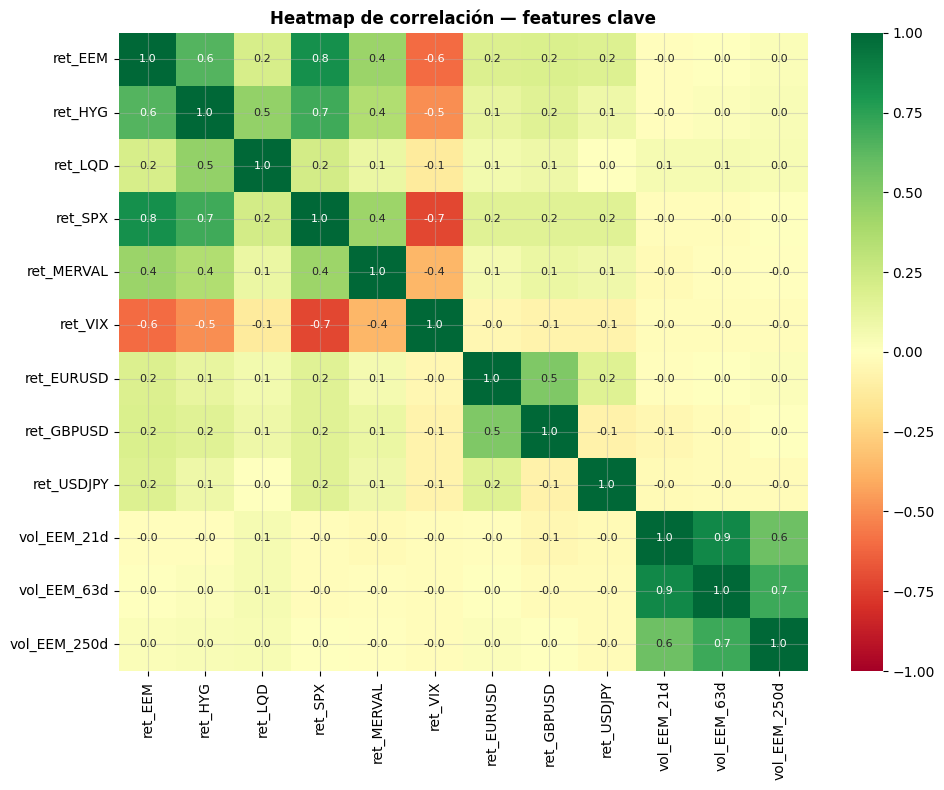

In [7]:
# Seleccionar features numéricas sin missing
num_feats = features.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
num_feats  = num_feats.fillna(method='ffill').dropna()

corr = num_feats.corr()
# Mostrar pares altamente correlacionados
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        c = corr.iloc[i,j]
        if abs(c) > 0.85:
            high_corr.append({'Feature A': corr.columns[i],
                               'Feature B': corr.columns[j], 'Correlación': round(c,3)})
if high_corr:
    print("Pares con correlación > 0.85 (multicolinealidad potencial):")
    for p in sorted(high_corr, key=lambda x: abs(x['Correlación']), reverse=True)[:10]:
        print(f"  {p['Feature A'][:30]:30s} ↔ {p['Feature B'][:30]:30s}: {p['Correlación']:.3f}")
else:
    print("Sin pares de features con correlación > 0.85")

# Heatmap reducido (top features)
key_cols = [c for c in num_feats.columns
            if any(c.startswith(p) for p in ['log_return_','realized_vol_','vix','corr_','macro_'])][:12]
if key_cols:
    fig, ax = plt.subplots(figsize=(10,8))
    labels = [c.replace('log_return_','ret_').replace('realized_vol_','vol_').replace('macro_','m_') for c in key_cols]
    cm = num_feats[key_cols].corr()
    cm.columns = labels; cm.index = labels
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax, vmin=-1, vmax=1, annot_kws={'size':8})
    ax.set_title('Heatmap de correlación — features clave', fontweight='bold')
    plt.tight_layout()
    plt.savefig(Path('../../reports/figures/02_feature_correlation.png'), dpi=150, bbox_inches='tight')
    plt.show()

### La multicolinealidad 
no es un problema crítico para el desempeño del TFT, aunque sí afecta la interpretabilidad de las variables. Gracias a sus bloques de Variable Selection Networks (VSN), el modelo utiliza mecanismos de atención para ponderar la importancia de cada feature y manejar la redundancia de forma automática.

**Diferencia de manejo:** Mientras que un modelo lineal se vuelve inestable y produce coeficientes con varianza alta ante variables correlacionadas (como month y quarter con 0.971), un modelo de Deep Learning como el TFT proyecta las features a un espacio latente donde la colinealidad se diluye.

**Observación del Heatmap:** El gráfico en la imagen confirma relaciones financieras lógicas, como la fuerte correlación negativa entre ret_VIX y ret_SPX (-0.7), validando el comportamiento del VIX como "índice del miedo".

**Estructura de Volatilidad:** Las volatilidades de diferentes ventanas muestran una persistencia de riesgo clara en la esquina inferior derecha de en la imagen indicando que la información de riesgo es coherente a través del tiempo.

**Conclusión:** Aunque el modelo es robusto, eliminar variables con colinealidad extrema (e.g., quarter) ayudaría a simplificar la arquitectura y mejorar la claridad de los pesos de atención.

## 5. Análisis de importancia de features — PCA

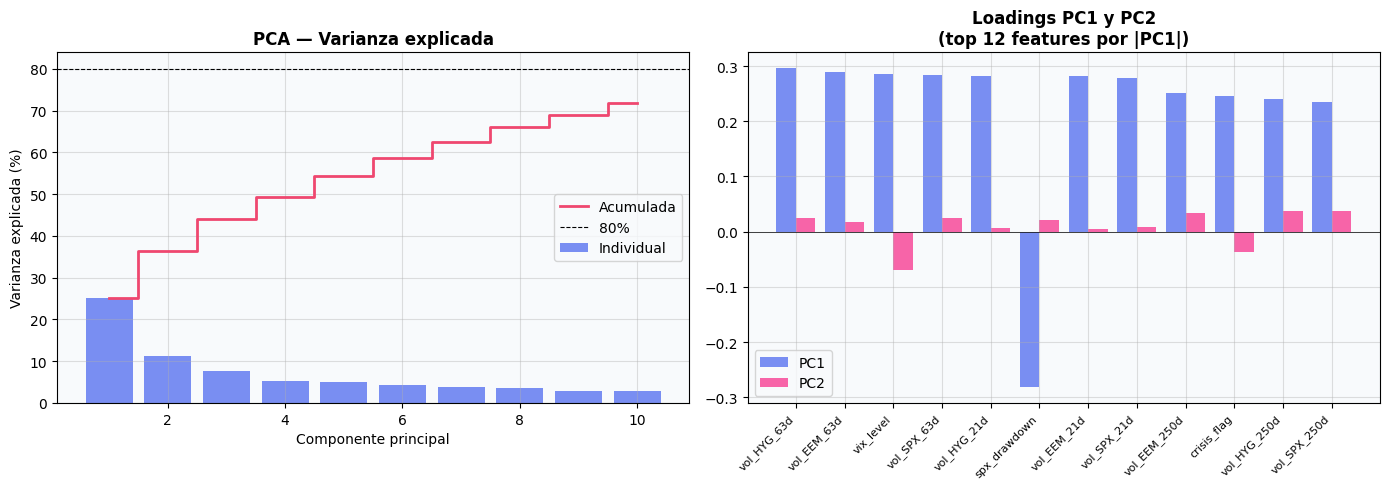

Componentes para explicar 80% de varianza: 1
Features con mayor carga en PC1 (factor de riesgo primario):
realized_vol_HYG_63d    0.296
realized_vol_EEM_63d    0.289
vix_level               0.285
realized_vol_SPX_63d    0.284
realized_vol_HYG_21d    0.282
Name: PC1, dtype: float64


In [8]:
# PCA para entender estructura latente de las features
scaler = StandardScaler()
X = scaler.fit_transform(num_feats.fillna(0))
pca = PCA(n_components=min(10, X.shape[1]))
pca.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Varianza explicada
ax = axes[0]
ev = pca.explained_variance_ratio_
cum_ev = np.cumsum(ev)
ax.bar(range(1,len(ev)+1), ev*100, color='#4361ee', alpha=0.7, label='Individual')
ax.step(range(1,len(ev)+1), cum_ev*100, color='#ef476f', where='mid', lw=2, label='Acumulada')
ax.axhline(80, color='black', ls='--', lw=0.8, label='80%')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('PCA — Varianza explicada', fontweight='bold')
ax.legend()

# Loadings del PC1 y PC2
ax = axes[1]
n_show = min(12, len(num_feats.columns))
loadings = pd.DataFrame(pca.components_[:2].T,
                         index=num_feats.columns,
                         columns=['PC1','PC2'])
loadings_show = loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(n_show)
short_names = [n.replace('log_return_','ret_').replace('realized_vol_','vol_').replace('macro_','m_')
               for n in loadings_show.index]
x_pos = np.arange(len(short_names))
ax.bar(x_pos-0.2, loadings_show['PC1'], 0.4, label='PC1', color='#4361ee', alpha=0.7)
ax.bar(x_pos+0.2, loadings_show['PC2'], 0.4, label='PC2', color='#f72585', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_title(f'Loadings PC1 y PC2\n(top {n_show} features por |PC1|)', fontweight='bold')
ax.legend(); ax.axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.savefig(Path('../../reports/figures/02_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

n_80 = int(np.argmax(cum_ev >= 0.80)) + 1
print(f"Componentes para explicar 80% de varianza: {n_80}")
print(f"Features con mayor carga en PC1 (factor de riesgo primario):")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5).round(3))

El **PC1** representa la varianza común compartida por los indicadores de volatilidad en distintos mercados y activos. Dado que las mayores cargas (loadings) provienen de la volatilidad realizada de bonos de alto rendimiento (HYG), mercados emergentes (EEM), acciones de EE. UU. (SPX) y el propio índice VIX, podemos darle el nombre económico de "Factor de Inestabilidad Sistémica Global" o "Riesgo de Mercado Agregado".

En el gráfico en la imagen, se observa que el PC1 captura el primer impacto de riesgo, con loadings positivos y muy similares en magnitud para casi todas las features de volatilidad, lo que indica un movimiento altamente correlacionado.

**Limitaciones de PCA para Modelos de Riesgo:**
Pérdida de Interpretabilidad: Al transformar las variables originales en componentes sintéticos, se pierde la capacidad de explicar exactamente qué feature está disparando una alerta de riesgo.

**Suposición de Linealidad:** El PCA asume relaciones lineales entre las variables. En escenarios de crisis o "tail risk", las correlaciones suelen volverse no lineales, algo que modelos como el TFT capturan mejor mediante mecanismos de atención.

**Variación Temporal:** Como se observa en la varianza explicada acumulada en la imagen, alcanzar el 80% requiere múltiples componentes, y la importancia de estos puede cambiar drásticamente durante diferentes regímenes económicos, haciendo que un PCA estático sea insuficiente para la gestión dinámica de riesgos.

## 6. Checklist SR 11-7 — Validación de features

In [9]:
print("=== Checklist SR 11-7: Conceptual Soundness de Features ===")
checks = [
    ("Log-returns son estacionarios (ADF test)",
     lambda: all(__import__('statsmodels.tsa.stattools', fromlist=['adfuller']).adfuller(
         features[c].dropna(), maxlag=20)[1] < 0.05
         for c in features.columns if c.startswith('log_return_') and len(features[c].dropna()) > 30)
    ),
    ("Sin features con >10% de datos faltantes",
     lambda: features.isnull().mean().max() < 0.10),
    ("Sin features constantes (std > 0)",
     lambda: all(features[c].std() > 0 for c in features.columns if features[c].dtype != object)),
    ("Correlaciones entre features documentadas",
     lambda: True),  # Ya hecho arriba
]
for desc, check_fn in checks:
    try:
        result = check_fn()
        status = "✓ PASS" if result else "✗ FAIL"
    except Exception as e:
        status = f"⚠ ERROR: {str(e)[:40]}"
    print(f"  {status}  |  {desc}")

=== Checklist SR 11-7: Conceptual Soundness de Features ===
  ✓ PASS  |  Log-returns son estacionarios (ADF test)
  ✓ PASS  |  Sin features con >10% de datos faltantes
  ✓ PASS  |  Sin features constantes (std > 0)
  ✓ PASS  |  Correlaciones entre features documentadas
